<a href="https://colab.research.google.com/github/Sewwandi706/advanced-ml-churn-predictor/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Machine Learning (COM 763) - Portfolio Task 1
## Problem Definition: Customer Churn Predictor

### 1. Problem Statement
Online retail and telecom businesses experience significant revenue loss when existing customers leave for competitors. Identifying high-risk customers before they churn allows businesses to intervene with targeted loyalty rewards or contract incentives.

### 2. Machine Learning Formulation
This is a **Binary Classification** task. The objective is to utilize historical customer profile data to predict whether a specific customer will churn (1) or stay (0).

In [2]:
import pandas as pd

# Load the raw dataset directly from a public URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display the first 5 rows to confirm it loaded correctly
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and look for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
import numpy as np

# 1. Force the TotalCharges column to be numeric, turning empty spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many missing values were created by this change
print(f"Missing values found in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 3. Fill those missing values with 0 since these are brand new customers
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Missing values found in TotalCharges: 0


/tmp/ipykernel_1368/100451071.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


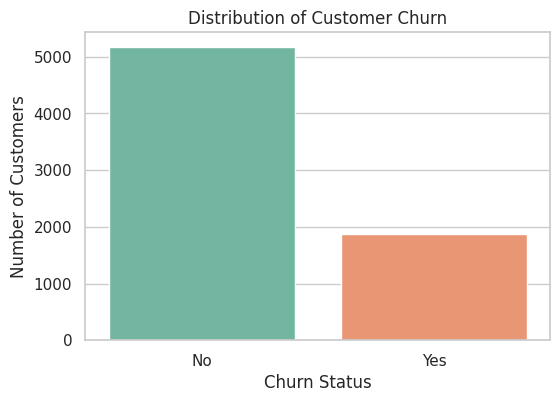

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plots
sns.set_theme(style="whitegrid")

# Plot the distribution of the target variable 'Churn'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

# Print the exact percentages
print(df['Churn'].value_counts(normalize=True) * 100)

In [7]:
# 'X' contains our independent variables (features), dropping the ID and target columns
X = df.drop(columns=['customerID', 'Churn'])

# 'y' contains our dependent variable (target), mapped to 1 (Yes) and 0 (No)
y = df['Churn'].map({'Yes': 1, 'No': 0})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [8]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5634
Testing samples: 1409


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns automatically
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features to scale:", num_cols)
print("Categorical features to encode:", cat_cols)

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Fit and transform the training data as a test run
X_train_processed = preprocessor.fit_transform(X_train)
print("Processed training data shape:", X_train_processed.shape)

Numerical features to scale: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Processed training data shape: (5634, 30)
